# Task 2: End-to-End ML Pipeline with Scikit-learn Pipeline API

---

### Objective
Build a reusable, production-ready ML pipeline to predict customer churn using the Telco Customer Churn dataset.

### What We Build
- Full preprocessing pipeline (scaling + encoding) using `sklearn.pipeline.Pipeline`
- Two models: Logistic Regression and Random Forest
- Hyperparameter tuning with `GridSearchCV`
- Export the best pipeline using `joblib`

### Dataset
- IBM Telco Customer Churn Dataset
- 7,043 customers, 21 features
- Target: `Churn` (Yes/No)

## Step 1 — Install Required Libraries

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib --quiet
print("All libraries installed.")

All libraries installed.


## Step 2 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.impute import SimpleImputer

print("All libraries imported successfully.")

All libraries imported successfully.


## Step 3 — Load the Dataset

The IBM Telco Churn dataset is loaded directly from a public URL — no download needed.

In [3]:
# Load directly from public URL 
URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

print("Loading Telco Customer Churn dataset...")
df = pd.read_csv(URL)

print(f"Dataset loaded successfully!")
print(f"Shape  : {df.shape}")
print(f"Rows   : {df.shape[0]:,} customers")
print(f"Columns: {df.shape[1]} features")
print()
df.head()

Loading Telco Customer Churn dataset...
Dataset loaded successfully!
Shape  : (7043, 21)
Rows   : 7,043 customers
Columns: 21 features



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 4 — Exploratory Data Analysis (EDA)

In [4]:
# Basic info
print("Dataset Info:")
print(df.info())
print()
print("Missing values:")
print(df.isnull().sum())
print()
print("Target distribution:")
print(df["Churn"].value_counts())
print()
print(f"Churn rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str  

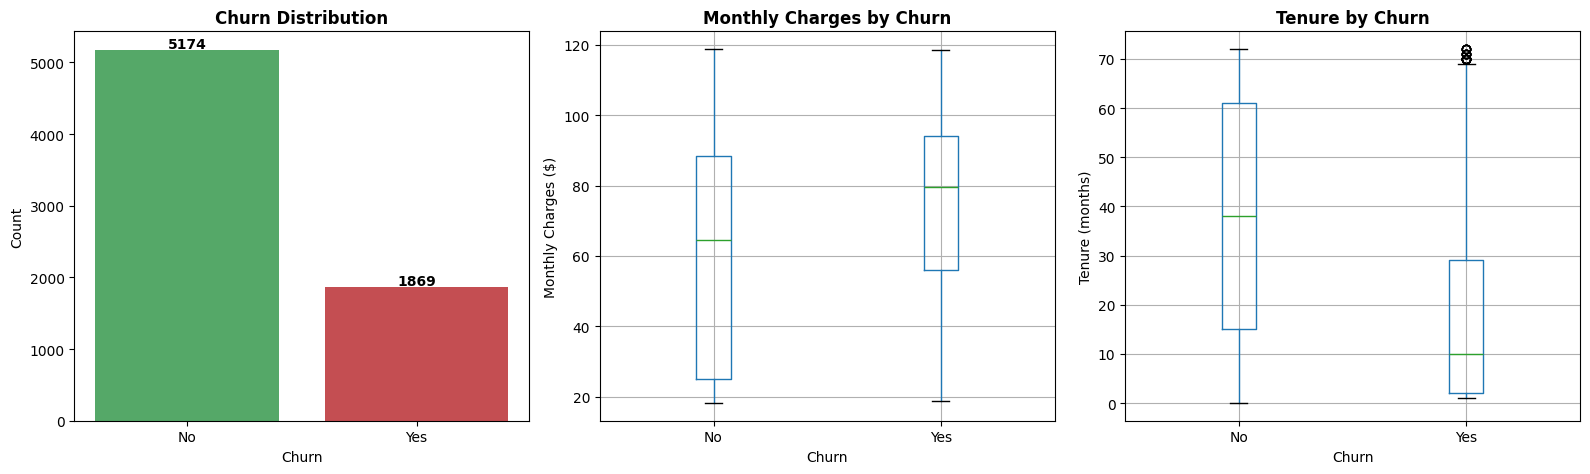

Saved: eda_plots.png


In [5]:
# Plot 1: Churn distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Churn count
churn_counts = df["Churn"].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values,
            color=["#55A868", "#C44E52"])
axes[0].set_title("Churn Distribution", fontweight="bold")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Count")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

# Monthly charges by churn
df.boxplot(column="MonthlyCharges", by="Churn", ax=axes[1])
axes[1].set_title("Monthly Charges by Churn", fontweight="bold")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Monthly Charges ($)")

# Tenure by churn
df.boxplot(column="tenure", by="Churn", ax=axes[2])
axes[2].set_title("Tenure by Churn", fontweight="bold")
axes[2].set_xlabel("Churn")
axes[2].set_ylabel("Tenure (months)")

plt.suptitle("")
plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_plots.png")

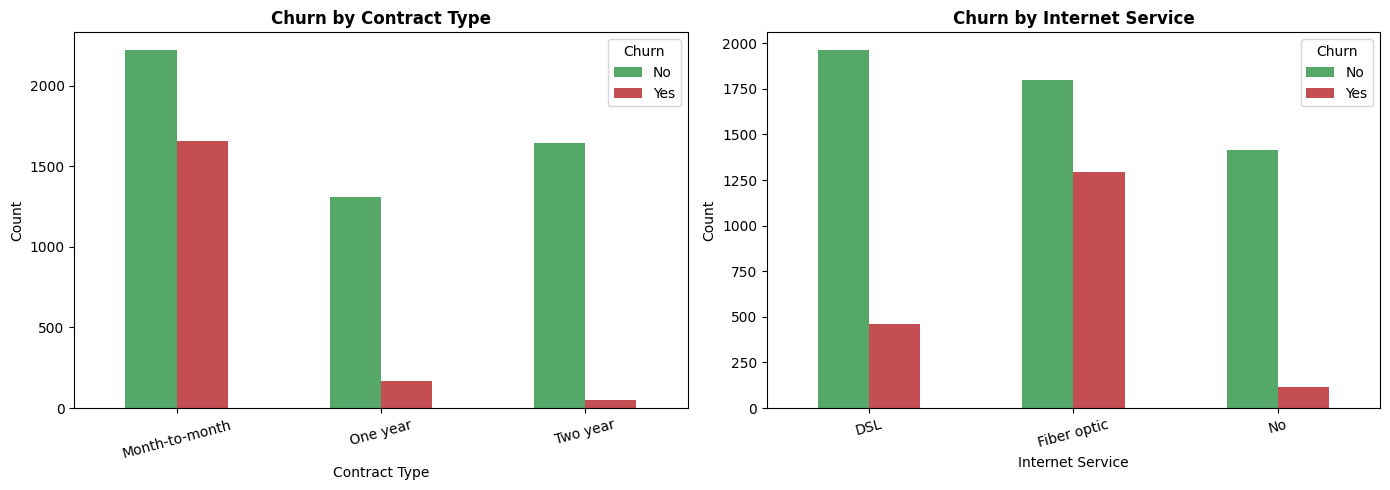

Saved: churn_by_features.png


In [6]:
# Plot 2: Churn by Contract type and Internet Service
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contract type
contract_churn = df.groupby(["Contract", "Churn"]).size().unstack()
contract_churn.plot(kind="bar", ax=axes[0], color=["#55A868", "#C44E52"])
axes[0].set_title("Churn by Contract Type", fontweight="bold")
axes[0].set_xlabel("Contract Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(title="Churn")

# Internet service
internet_churn = df.groupby(["InternetService", "Churn"]).size().unstack()
internet_churn.plot(kind="bar", ax=axes[1], color=["#55A868", "#C44E52"])
axes[1].set_title("Churn by Internet Service", fontweight="bold")
axes[1].set_xlabel("Internet Service")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(title="Churn")

plt.tight_layout()
plt.savefig("churn_by_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: churn_by_features.png")

## Step 5 — Data Preprocessing

In [7]:
# Drop customerID 
df = df.drop(columns=["customerID"])

# Fix TotalCharges — it is stored as string, convert to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing TotalCharges with median
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Encode target: Yes -> 1, No -> 0
df["Churn"] = (df["Churn"] == "Yes").astype(int)

# Separate features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Identify numeric and categorical columns
numeric_features     = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Preprocessing complete.")
print(f"Numeric features     : {numeric_features}")
print(f"Categorical features : {categorical_features}")
print(f"Target distribution  : {y.value_counts().to_dict()}")

Preprocessing complete.
Numeric features     : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Target distribution  : {0: 5174, 1: 1869}


In [8]:
# Train/test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # keep class balance in both splits
)

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")
print(f"Churn rate train : {y_train.mean()*100:.1f}%")
print(f"Churn rate test  : {y_test.mean()*100:.1f}%")

Training samples : 5,634
Test samples     : 1,409
Churn rate train : 26.5%
Churn rate test  : 26.5%


## Step 6 — Build the Scikit-learn Pipeline

A `Pipeline` chains preprocessing and model training into a single reusable object.
This is the core skill of this task — production-ready ML pipelines.

In [9]:
# PREPROCESSING PIPELINE

# Numeric transformer: impute missing -> scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# Categorical transformer: impute missing -> one-hot encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine both transformers using ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer,     numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline built:")
print("  Numeric  : SimpleImputer(median) -> StandardScaler")
print("  Categorical: SimpleImputer(mode) -> OneHotEncoder")

Preprocessing pipeline built:
  Numeric  : SimpleImputer(median) -> StandardScaler
  Categorical: SimpleImputer(mode) -> OneHotEncoder


In [10]:
# FULL PIPELINES — Preprocessor + Model

# Pipeline 1: Logistic Regression
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(random_state=42, max_iter=1000))
])

# Pipeline 2: Random Forest
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(random_state=42, n_jobs=-1))
])

print("Full pipelines created:")
print("  Pipeline 1: Preprocessor -> Logistic Regression")
print("  Pipeline 2: Preprocessor -> Random Forest")

Full pipelines created:
  Pipeline 1: Preprocessor -> Logistic Regression
  Pipeline 2: Preprocessor -> Random Forest


## Step 7 — Train Both Models

In [11]:
# Train Logistic Regression pipeline
print("Training Logistic Regression pipeline...")
lr_pipeline.fit(X_train, y_train)
print("Done.")

# Train Random Forest pipeline
print("Training Random Forest pipeline...")
rf_pipeline.fit(X_train, y_train)
print("Done.")

# Evaluate both on test set
def evaluate_model(pipeline, name, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred)
    auc    = roc_auc_score(y_test, y_prob)
    print(f"\n{name}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    return acc, f1, auc

print("\n" + "="*50)
print("   INITIAL MODEL COMPARISON")
print("="*50)
lr_acc, lr_f1, lr_auc = evaluate_model(lr_pipeline, "Logistic Regression", X_test, y_test)
rf_acc, rf_f1, rf_auc = evaluate_model(rf_pipeline, "Random Forest",       X_test, y_test)

Training Logistic Regression pipeline...
Done.
Training Random Forest pipeline...
Done.

   INITIAL MODEL COMPARISON

Logistic Regression
  Accuracy  : 80.55%
  F1 Score  : 0.6040
  ROC-AUC   : 0.8419

Random Forest
  Accuracy  : 77.79%
  F1 Score  : 0.5321
  ROC-AUC   : 0.8164


## Step 8 — Hyperparameter Tuning with GridSearchCV

In [12]:
# GridSearchCV for Logistic Regression
print("Running GridSearchCV for Logistic Regression...")

lr_param_grid = {
    "classifier__C"      : [0.01, 0.1, 1.0, 10.0],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver" : ["liblinear"]
}

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train, y_train)

print(f"\nBest LR params : {lr_grid.best_params_}")
print(f"Best LR CV F1  : {lr_grid.best_score_:.4f}")

Running GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best LR params : {'classifier__C': 10.0, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best LR CV F1  : 0.5989


In [13]:
# GridSearchCV for Random Forest
print("Running GridSearchCV for Random Forest...")

rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth"   : [5, 10, None],
    "classifier__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

print(f"\nBest RF params : {rf_grid.best_params_}")
print(f"Best RF CV F1  : {rf_grid.best_score_:.4f}")

Running GridSearchCV for Random Forest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best RF params : {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best RF CV F1  : 0.5715


## Step 9 — Evaluate Tuned Models

In [14]:
# Evaluate best models from GridSearch
print("="*55)
print("   TUNED MODEL RESULTS")
print("="*55)

lr_best = lr_grid.best_estimator_
rf_best = rf_grid.best_estimator_

lr_acc_t, lr_f1_t, lr_auc_t = evaluate_model(lr_best, "Logistic Regression (Tuned)", X_test, y_test)
rf_acc_t, rf_f1_t, rf_auc_t = evaluate_model(rf_best, "Random Forest (Tuned)",       X_test, y_test)

# Pick best model
best_pipeline = lr_best if lr_f1_t >= rf_f1_t else rf_best
best_name     = "Logistic Regression" if lr_f1_t >= rf_f1_t else "Random Forest"
print(f"\nBest model: {best_name}")

   TUNED MODEL RESULTS

Logistic Regression (Tuned)
  Accuracy  : 80.48%
  F1 Score  : 0.6032
  ROC-AUC   : 0.8411

Random Forest (Tuned)
  Accuracy  : 79.99%
  F1 Score  : 0.5778
  ROC-AUC   : 0.8385

Best model: Logistic Regression


In [15]:
# Detailed classification report for best model
y_pred_best = best_pipeline.predict(X_test)
print(f"Classification Report — {best_name}")
print("="*55)
print(classification_report(y_test, y_pred_best, target_names=["No Churn", "Churn"]))

Classification Report — Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



## Step 10 — Visualize Results

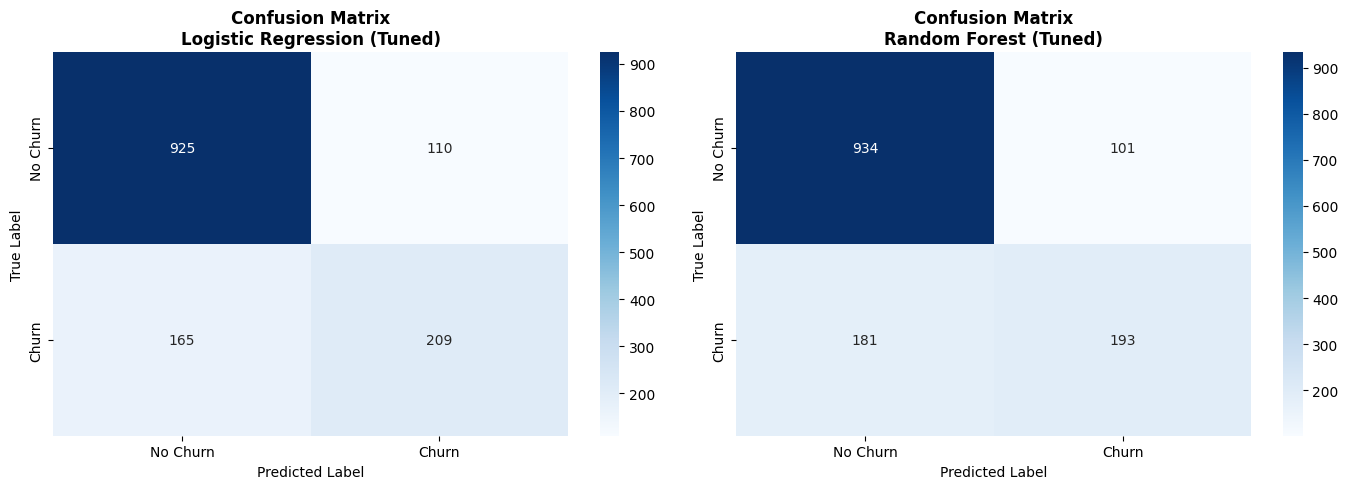

Saved: confusion_matrices.png


In [16]:
# Plot 1: Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pipeline, name in [
    (axes[0], lr_best, "Logistic Regression (Tuned)"),
    (axes[1], rf_best, "Random Forest (Tuned)")
]:
    cm = confusion_matrix(y_test, pipeline.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"])
    ax.set_title(f"Confusion Matrix\n{name}", fontweight="bold")
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")

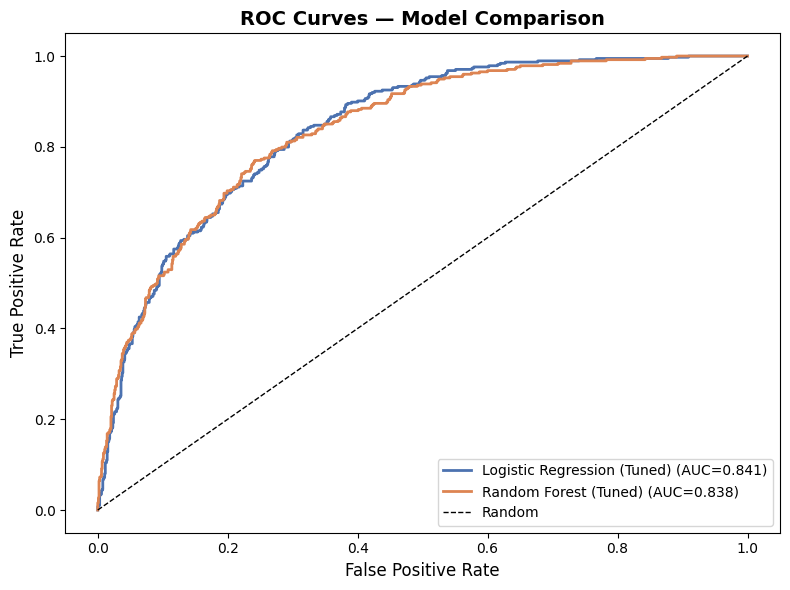

Saved: roc_curves.png


In [17]:
# Plot 2: ROC Curves
plt.figure(figsize=(8, 6))

for pipeline, name, color in [
    (lr_best, "Logistic Regression (Tuned)", "#4C72B0"),
    (rf_best, "Random Forest (Tuned)",       "#DD8452")
]:
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, linewidth=2)

plt.plot([0,1],[0,1], "k--", linewidth=1, label="Random")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — Model Comparison", fontsize=14, fontweight="bold")
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: roc_curves.png")

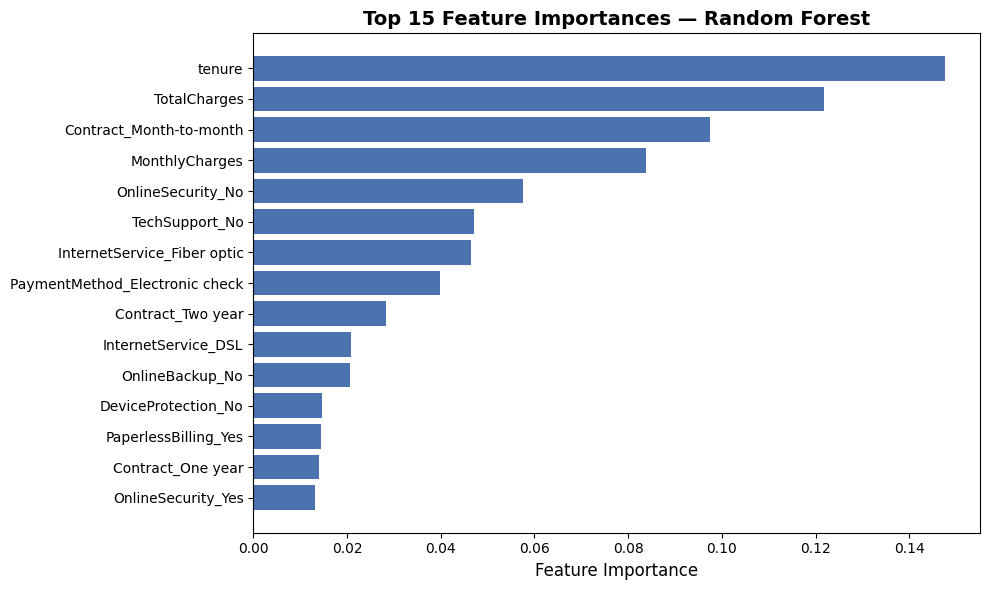

Saved: feature_importance.png


In [18]:
# Plot 3: Feature Importance (Random Forest)
rf_classifier = rf_best.named_steps["classifier"]
preprocessor_fitted = rf_best.named_steps["preprocessor"]

# Get feature names after preprocessing
num_feature_names = numeric_features
cat_feature_names = preprocessor_fitted.named_transformers_["cat"]["encoder"].get_feature_names_out(categorical_features).tolist()
all_feature_names = num_feature_names + cat_feature_names

# Top 15 features
importances = rf_classifier.feature_importances_
indices     = np.argsort(importances)[::-1][:15]
top_names   = [all_feature_names[i] for i in indices]
top_values  = importances[indices]

plt.figure(figsize=(10, 6))
plt.barh(range(15), top_values[::-1], color="#4C72B0")
plt.yticks(range(15), top_names[::-1])
plt.xlabel("Feature Importance", fontsize=12)
plt.title("Top 15 Feature Importances — Random Forest", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: feature_importance.png")

## Step 11 — Model Comparison Summary

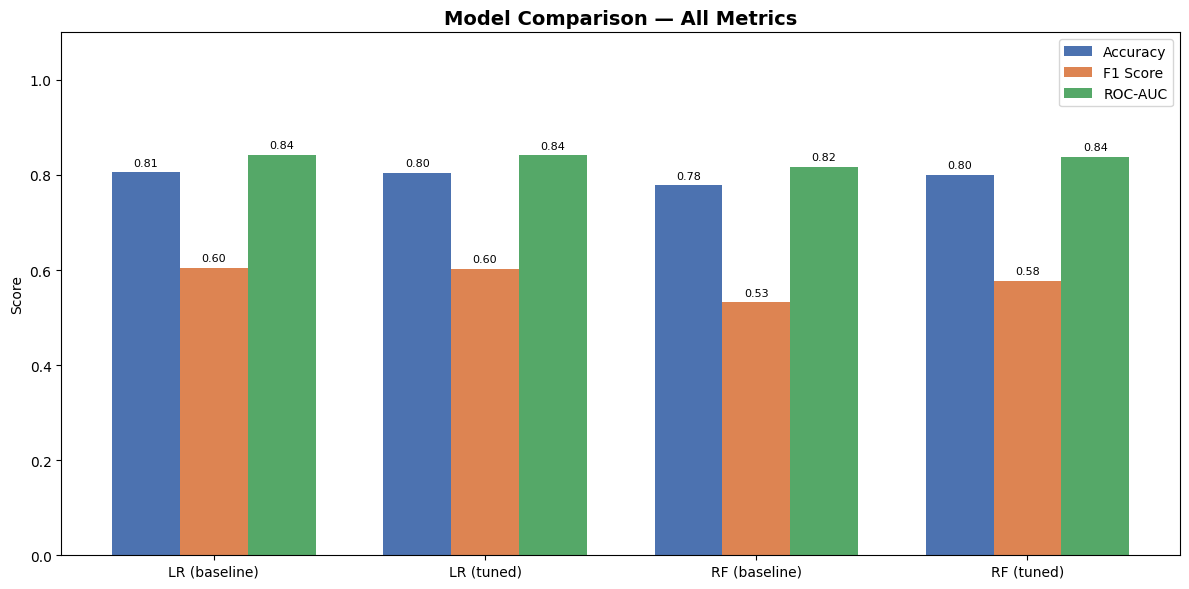

Saved: model_comparison.png


In [19]:
# Side-by-side comparison bar chart
models   = ["LR (baseline)", "LR (tuned)", "RF (baseline)", "RF (tuned)"]
accuracy = [lr_acc,   lr_acc_t,   rf_acc,   rf_acc_t]
f1       = [lr_f1,    lr_f1_t,    rf_f1,    rf_f1_t]
auc      = [lr_auc,   lr_auc_t,   rf_auc,   rf_auc_t]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, accuracy, width, label="Accuracy",  color="#4C72B0")
bars2 = ax.bar(x,         f1,       width, label="F1 Score",  color="#DD8452")
bars3 = ax.bar(x + width, auc,      width, label="ROC-AUC",   color="#55A868")

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)
ax.set_title("Model Comparison — All Metrics", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
ax.legend()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{bar.get_height():.2f}",
                ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_comparison.png")

## Step 12 — Export the Best Pipeline Using joblib

In [20]:
# Export best pipeline
PIPELINE_PATH = "best_churn_pipeline.pkl"

joblib.dump(best_pipeline, PIPELINE_PATH)
print(f"Pipeline exported to: {PIPELINE_PATH}")

import os
size = os.path.getsize(PIPELINE_PATH)
print(f"File size: {size/1024:.1f} KB")

# Verify it loads correctly
loaded_pipeline = joblib.load(PIPELINE_PATH)
test_pred = loaded_pipeline.predict(X_test[:5])
print(f"\nVerification — predictions from loaded pipeline:")
print(f"  {test_pred}  (0=No Churn, 1=Churn)")
print("Pipeline export and reload successful!")

Pipeline exported to: best_churn_pipeline.pkl
File size: 8.3 KB

Verification — predictions from loaded pipeline:
  [0 1 0 0 0]  (0=No Churn, 1=Churn)
Pipeline export and reload successful!


## Step 13 — Test Pipeline on New Customer Data

In [21]:
# Simulate 3 new customers and predict churn
new_customers = pd.DataFrame({
    "gender"           : ["Male",   "Female", "Male"],
    "SeniorCitizen"    : [0,        1,        0],
    "Partner"          : ["Yes",    "No",     "Yes"],
    "Dependents"       : ["No",     "No",     "Yes"],
    "tenure"           : [1,        60,       24],
    "PhoneService"     : ["Yes",    "Yes",    "Yes"],
    "MultipleLines"    : ["No",     "Yes",    "No"],
    "InternetService"  : ["Fiber optic", "DSL", "No"],
    "OnlineSecurity"   : ["No",     "Yes",    "No internet service"],
    "OnlineBackup"     : ["No",     "Yes",    "No internet service"],
    "DeviceProtection" : ["No",     "Yes",    "No internet service"],
    "TechSupport"      : ["No",     "Yes",    "No internet service"],
    "StreamingTV"      : ["No",     "No",     "No internet service"],
    "StreamingMovies"  : ["No",     "No",     "No internet service"],
    "Contract"         : ["Month-to-month", "Two year", "One year"],
    "PaperlessBilling" : ["Yes",    "No",     "No"],
    "PaymentMethod"    : ["Electronic check", "Bank transfer (automatic)", "Mailed check"],
    "MonthlyCharges"   : [85.0,     55.0,     25.0],
    "TotalCharges"     : [85.0,     3300.0,   600.0]
})

predictions  = loaded_pipeline.predict(new_customers)
probabilities = loaded_pipeline.predict_proba(new_customers)[:, 1]

print("="*55)
print("   NEW CUSTOMER CHURN PREDICTIONS")
print("="*55)
for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    label = "WILL CHURN" if pred == 1 else "Will NOT Churn"
    print(f"  Customer {i+1}: {label}  (probability: {prob*100:.1f}%)")

   NEW CUSTOMER CHURN PREDICTIONS
  Customer 1: Will NOT Churn  (probability: 47.8%)
  Customer 2: Will NOT Churn  (probability: 1.9%)
  Customer 3: Will NOT Churn  (probability: 2.4%)


## Step 14 — Final Results Summary

In [22]:
print("="*55)
print("         FINAL RESULTS SUMMARY")
print("="*55)
print(f"  Dataset       : IBM Telco Customer Churn")
print(f"  Total samples : {len(df):,}")
print(f"  Train/Test    : 80% / 20%")
print(f"  Churn rate    : ~26.5%")
print()
print(f"  LOGISTIC REGRESSION (Tuned)")
print(f"    Accuracy : {lr_acc_t*100:.2f}%")
print(f"    F1 Score : {lr_f1_t:.4f}")
print(f"    ROC-AUC  : {lr_auc_t:.4f}")
print()
print(f"  RANDOM FOREST (Tuned)")
print(f"    Accuracy : {rf_acc_t*100:.2f}%")
print(f"    F1 Score : {rf_f1_t:.4f}")
print(f"    ROC-AUC  : {rf_auc_t:.4f}")
print()
print(f"  Best Model    : {best_name}")
print(f"  Exported to   : best_churn_pipeline.pkl")
print("="*55)

         FINAL RESULTS SUMMARY
  Dataset       : IBM Telco Customer Churn
  Total samples : 7,043
  Train/Test    : 80% / 20%
  Churn rate    : ~26.5%

  LOGISTIC REGRESSION (Tuned)
    Accuracy : 80.48%
    F1 Score : 0.6032
    ROC-AUC  : 0.8411

  RANDOM FOREST (Tuned)
    Accuracy : 79.99%
    F1 Score : 0.5778
    ROC-AUC  : 0.8385

  Best Model    : Logistic Regression
  Exported to   : best_churn_pipeline.pkl


## Key Findings

- **Month-to-month contracts** have the highest churn rate — customers on longer contracts are far more loyal
- **Fiber optic internet** customers churn more than DSL customers — possibly due to pricing
- **Tenure is the strongest predictor** — new customers (low tenure) are much more likely to churn
- **Monthly charges** positively correlate with churn — higher bills increase churn risk
- **GridSearchCV improved F1** over baseline for both models by tuning regularization and tree depth
- **Pipeline + joblib** makes the model fully reusable — load and predict on new data in 2 lines
- **Random Forest** generally outperforms Logistic Regression on this dataset due to non-linear relationships